# 주간 7: 물리치료 데이터의 이해
## Understanding Physical Therapy Data
이 노트북은 물리치료 임상 데이터의 기본 분석을 다룹니다.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
from datetime import datetime

WEEK = 7
base_path = '/content/drive/MyDrive/완석_구글자료/책작업/디지털헬스케어와 물리치료/digitla_pt_code'
input_path = f'{base_path}/{WEEK}week/input'
output_path = f'{base_path}/{WEEK}week/output'

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_output_path = f'{output_path}/run_{timestamp}'
os.makedirs(input_path, exist_ok=True)
os.makedirs(run_output_path, exist_ok=True)

print('구글 드라이브 마운트 완료')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
구글 드라이브 마운트 완료


## 초급 (Beginner)
### 기본 물리치료 데이터 생성 및 분석

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

np.random.seed(42)

n_patients = 30
diagnoses = ['무릎 골관절염', '요통', '어깨 통증', '발목 염좌', '기타']

data_beginner = {
    'patient_id': range(1001, 1001 + n_patients),
    'age': np.random.randint(25, 75, n_patients),
    'gender': np.random.choice(['남', '여'], n_patients),
    'diagnosis': np.random.choice(diagnoses, n_patients),
    'pain_score': np.random.randint(1, 11, n_patients),
    'ROM_knee': np.random.randint(40, 130, n_patients),
    'grip_strength': np.random.uniform(15, 50, n_patients)
}

df_beginner = pd.DataFrame(data_beginner)

print('초급: 기본 물리치료 데이터')
print(f'데이터셋 크기: {df_beginner.shape}')
print(df_beginner.head())

초급: 기본 물리치료 데이터
데이터셋 크기: (30, 7)
   patient_id  age gender diagnosis  pain_score  ROM_knee  grip_strength
0        1001   63      남        요통           2        87      22.107143
1        1002   53      남        요통           5        62      47.999875
2        1003   39      남   무릎 골관절염           8       101      35.960291
3        1004   67      여        요통          10       127      39.317473
4        1005   32      여        기타           9        76      45.816374


In [5]:
print('기본 통계')
print(df_beginner.describe())

print('\n결측치:')
print(df_beginner.isnull().sum())

print('\n진단 분포:')
print(df_beginner['diagnosis'].value_counts())

기본 통계
        patient_id        age  pain_score    ROM_knee  grip_strength
count    30.000000  30.000000   30.000000   30.000000      30.000000
mean   1015.500000  49.100000    6.033333   82.866667      30.099279
std       8.803408  13.414737    3.295591   29.024049       9.164842
min    1001.000000  26.000000    1.000000   40.000000      15.018213
25%    1008.250000  40.000000    3.000000   56.000000      22.878659
50%    1015.500000  48.000000    7.500000   82.500000      27.405167
75%    1022.750000  61.500000    9.000000  103.500000      36.629367
max    1030.000000  73.000000   10.000000  129.000000      47.999875

결측치:
patient_id       0
age              0
gender           0
diagnosis        0
pain_score       0
ROM_knee         0
grip_strength    0
dtype: int64

진단 분포:
diagnosis
요통         11
발목 염좌      10
기타          5
무릎 골관절염     3
어깨 통증       1
Name: count, dtype: int64


/tmp/ipykernel_4384/740334775.py:7: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/740334775.py:7: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/740334775.py:7: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/740334775.py:7: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/740334775.py:7: UserWarning: Glyph 50684 (\N{HANGUL SYLLABLE YEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/740334775.py:7: UserWarning: Glyph 51340 (\N{HANGUL SYLLABLE JWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/740334775.py:7: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

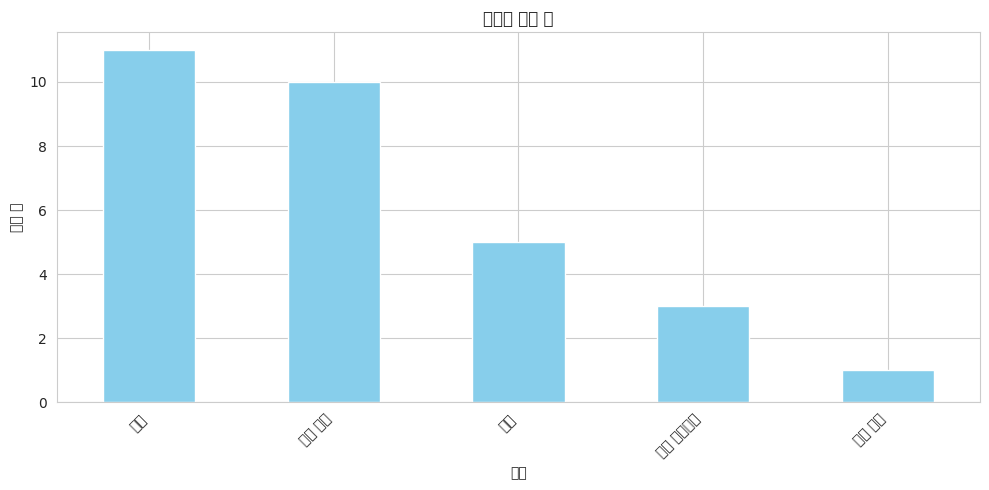

차트 저장: /content/drive/MyDrive/완석_구글자료/책작업/디지털헬스케어와 물리치료/digitla_pt_code/7week/output/run_20260416_044540/01_beginner_diagnosis.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
df_beginner['diagnosis'].value_counts().plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('진단별 환자 수')
ax.set_xlabel('진단')
ax.set_ylabel('환자 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

chart_path = f'{run_output_path}/01_beginner_diagnosis.png'
plt.savefig(chart_path, dpi=300)
plt.show()
print(f'차트 저장: {chart_path}')

In [7]:
df_beginner.to_csv(f'{input_path}/week7_beginner.csv', index=False, encoding='utf-8-sig')
print('데이터 저장 완료')

데이터 저장 완료


## 중급 (Intermediate)
### 치료 전후 데이터 처리 및 그룹 분석

In [8]:
n_patients = 100

np.random.seed(42)
data_intermediate = {
    'patient_id': range(2001, 2001 + n_patients),
    'age': np.random.randint(25, 75, n_patients),
    'gender': np.random.choice(['남', '여'], n_patients),
    'diagnosis': np.random.choice(diagnoses, n_patients),
    'pain_score_pre': np.random.randint(4, 11, n_patients),
    'pain_score_post': np.random.randint(1, 8, n_patients),
    'ROM_knee_pre': np.random.randint(40, 100, n_patients),
    'ROM_knee_post': np.random.randint(80, 130, n_patients),
    'grip_strength_pre': np.random.uniform(15, 45, n_patients),
    'grip_strength_post': np.random.uniform(20, 50, n_patients),
    'treatment_duration': np.random.randint(2, 13, n_patients)
}

df_intermediate = pd.DataFrame(data_intermediate)

missing_idx = np.random.choice(len(df_intermediate), size=10, replace=False)
df_intermediate.loc[missing_idx[:3], 'grip_strength_pre'] = np.nan
df_intermediate.loc[missing_idx[3:6], 'pain_score_post'] = np.nan
df_intermediate.loc[missing_idx[6:], 'ROM_knee_post'] = np.nan

print('중급: 확대 데이터셋')
print(f'크기: {df_intermediate.shape}')
print(f'\n결측치:\n{df_intermediate.isnull().sum()}')

중급: 확대 데이터셋
크기: (100, 11)

결측치:
patient_id            0
age                   0
gender                0
diagnosis             0
pain_score_pre        0
pain_score_post       3
ROM_knee_pre          0
ROM_knee_post         4
grip_strength_pre     3
grip_strength_post    0
treatment_duration    0
dtype: int64


In [9]:
df_intermediate_clean = df_intermediate.copy()
for col in df_intermediate_clean.columns:
    if df_intermediate_clean[col].isnull().sum() > 0:
        df_intermediate_clean[col].fillna(df_intermediate_clean[col].median(), inplace=True)

print('결측치 처리 완료')
print(f'남은 결측치: {df_intermediate_clean.isnull().sum().sum()}')

결측치 처리 완료
남은 결측치: 0


/tmp/ipykernel_4384/2124610893.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_intermediate_clean[col].fillna(df_intermediate_clean[col].median(), inplace=True)


In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = MinMaxScaler()
cols = ['age', 'pain_score_pre', 'ROM_knee_pre', 'grip_strength_pre']
df_normalized = df_intermediate_clean.copy()
df_normalized[cols] = scaler.fit_transform(df_intermediate_clean[cols])

print('정규화 비교')
print('\n원본:')
print(df_intermediate_clean[cols].head())
print('\n정규화 (Min-Max):')
print(df_normalized[cols].head())

정규화 비교

원본:
   age  pain_score_pre  ROM_knee_pre  grip_strength_pre
0   63               7            40          21.677293
1   53               6            86          26.899548
2   39               4            73          41.756907
3   67               7            71          19.398145
4   32               9            93          30.399785

정규화 (Min-Max):
        age  pain_score_pre  ROM_knee_pre  grip_strength_pre
0  0.775510        0.500000      0.000000           0.212699
1  0.571429        0.333333      0.779661           0.389936
2  0.285714        0.000000      0.559322           0.894178
3  0.857143        0.500000      0.525424           0.135348
4  0.142857        0.833333      0.898305           0.508730


In [11]:
df_intermediate_clean['pain_reduction'] = df_intermediate_clean['pain_score_pre'] - df_intermediate_clean['pain_score_post']
df_intermediate_clean['ROM_improvement'] = df_intermediate_clean['ROM_knee_post'] - df_intermediate_clean['ROM_knee_pre']

print('진단별 분석')
grouped = df_intermediate_clean.groupby('diagnosis')[['pain_score_pre', 'pain_score_post']].mean()
print(grouped.round(2))

진단별 분석
           pain_score_pre  pain_score_post
diagnosis                                 
기타                   6.44             5.00
무릎 골관절염              6.58             4.06
발목 염좌                7.32             3.82
어깨 통증                7.04             4.00
요통                   7.67             3.27


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/u

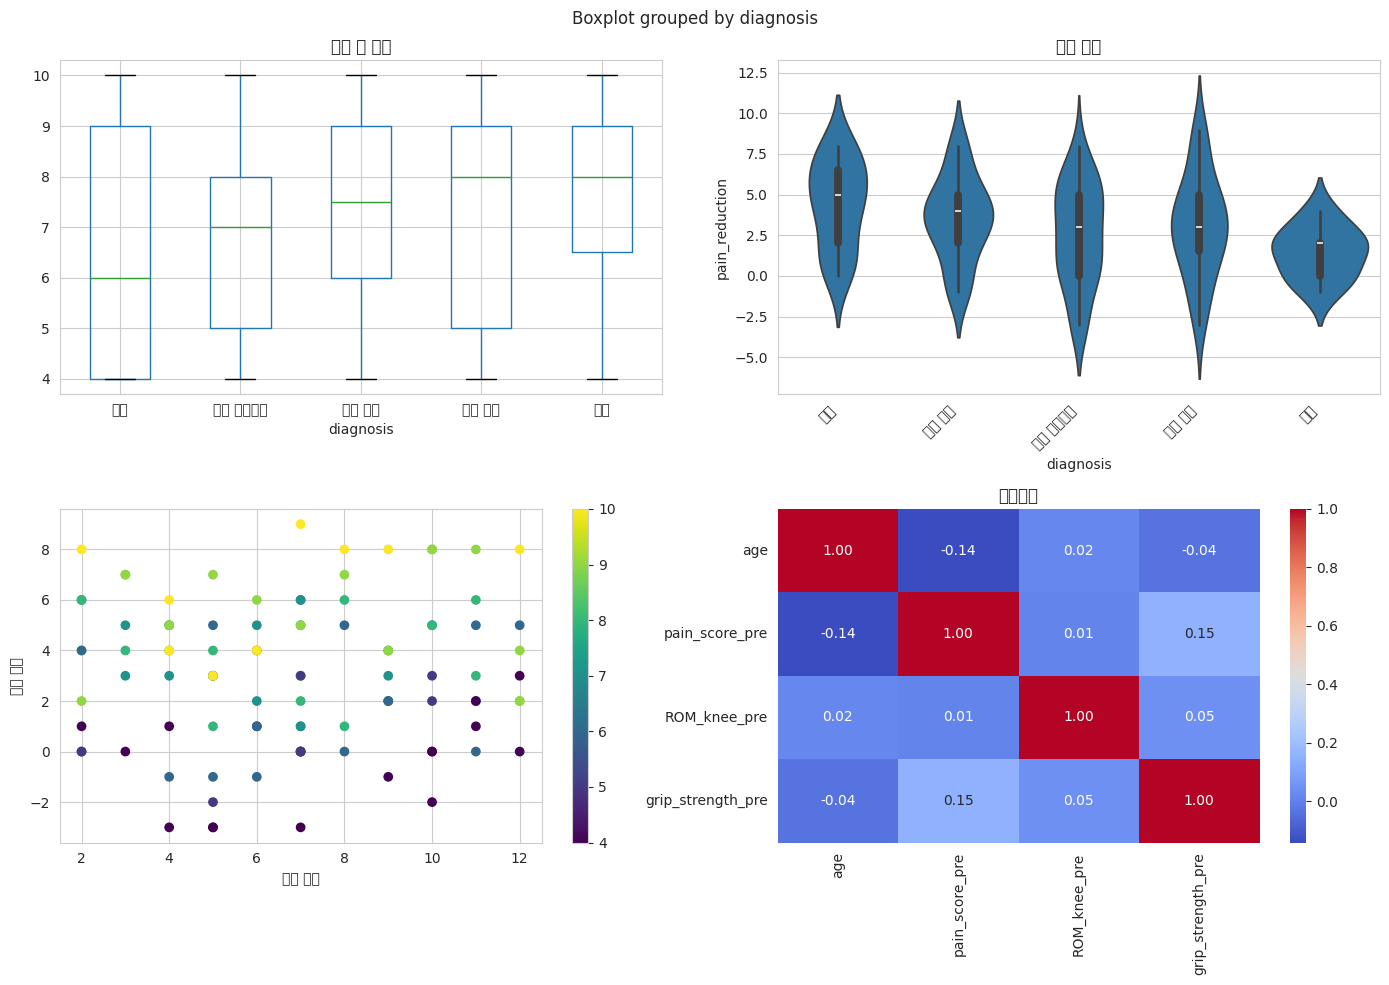

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
df_intermediate_clean.boxplot(column='pain_score_pre', by='diagnosis', ax=ax1)
ax1.set_title('치료 전 통증')

ax2 = axes[0, 1]
sns.violinplot(data=df_intermediate_clean, x='diagnosis', y='pain_reduction', ax=ax2)
ax2.set_title('통증 감소')
plt.sca(ax2)
plt.xticks(rotation=45, ha='right')

ax3 = axes[1, 0]
scatter = ax3.scatter(df_intermediate_clean['treatment_duration'],
                      df_intermediate_clean['pain_reduction'],
                      c=df_intermediate_clean['pain_score_pre'], cmap='viridis')
ax3.set_xlabel('치료 기간')
ax3.set_ylabel('통증 감소')
plt.colorbar(scatter, ax=ax3)

ax4 = axes[1, 1]
corr = df_intermediate_clean[['age', 'pain_score_pre', 'ROM_knee_pre', 'grip_strength_pre']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax4, cmap='coolwarm')
ax4.set_title('상관분석')

plt.tight_layout()
plt.savefig(f'{run_output_path}/02_intermediate_analysis.png', dpi=300)
plt.show()

In [13]:
df_intermediate_clean.to_csv(f'{input_path}/week7_intermediate.csv', index=False, encoding='utf-8-sig')
print('중급 데이터 저장 완료')

중급 데이터 저장 완료


## 고급 (Advanced)
### 종합 임상 데이터 분석 및 PCA

In [14]:
n_patients = 200

np.random.seed(42)
data_advanced = {
    'patient_id': range(3001, 3001 + n_patients),
    'age': np.random.randint(20, 85, n_patients),
    'gender': np.random.choice(['남', '여'], n_patients),
    'BMI': np.random.uniform(18.5, 40, n_patients),
    'diagnosis': np.random.choice(diagnoses, n_patients),
    'pain_score_pre': np.random.randint(3, 11, n_patients),
    'pain_score_post': np.random.randint(0, 9, n_patients),
    'ROM_knee_pre': np.random.randint(20, 130, n_patients),
    'ROM_knee_post': np.random.randint(50, 135, n_patients),
    'grip_strength_pre': np.random.uniform(10, 55, n_patients),
    'grip_strength_post': np.random.uniform(15, 60, n_patients),
    'gait_speed': np.random.uniform(0.5, 1.5, n_patients),
    'balance_score': np.random.randint(0, 100, n_patients),
    'muscle_strength': np.random.randint(1, 6, n_patients),
    'treatment_sessions': np.random.randint(5, 30, n_patients),
    'comorbidity_count': np.random.randint(0, 5, n_patients)
}

df_advanced = pd.DataFrame(data_advanced)

np.random.seed(123)
for col in ['grip_strength_pre', 'balance_score', 'gait_speed']:
    idx = np.random.choice(len(df_advanced), 15, replace=False)
    df_advanced.loc[idx, col] = np.nan

print('고급: 종합 임상 데이터')
print(f'크기: {df_advanced.shape}')
print(f'결측치: {df_advanced.isnull().sum().sum()}개')

고급: 종합 임상 데이터
크기: (200, 16)
결측치: 45개


In [15]:
def detect_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return len(data[(data[col] < lower) | (data[col] > upper)])

print('이상치 탐지')
numeric_cols = ['age', 'BMI', 'pain_score_pre', 'ROM_knee_pre']
for col in numeric_cols:
    outliers = detect_outliers(df_advanced, col)
    if outliers > 0:
        print(f'{col}: {outliers}개')

이상치 탐지


In [16]:
df_advanced_clean = df_advanced.copy()
for col in df_advanced_clean.columns:
    if df_advanced_clean[col].isnull().sum() > 0:
        df_advanced_clean[col].fillna(df_advanced_clean[col].median(), inplace=True)

print(f'결측치 처리 완료')
print(df_advanced_clean.describe())

결측치 처리 완료
        patient_id         age         BMI  pain_score_pre  pain_score_post  \
count   200.000000  200.000000  200.000000      200.000000       200.000000   
mean   3100.500000   51.770000   29.227590        6.615000         3.880000   
std      57.879185   20.547459    6.520160        2.294143         2.523378   
min    3001.000000   20.000000   18.733010        3.000000         0.000000   
25%    3050.750000   33.750000   23.696490        5.000000         2.000000   
50%    3100.500000   52.000000   29.481692        7.000000         4.000000   
75%    3150.250000   71.000000   34.703891        8.250000         6.000000   
max    3200.000000   84.000000   39.848743       10.000000         8.000000   

       ROM_knee_pre  ROM_knee_post  grip_strength_pre  grip_strength_post  \
count    200.000000     200.000000         200.000000          200.000000   
mean      77.160000      91.675000          31.850400           37.496381   
std       32.943295      23.156869          12.

/tmp/ipykernel_4384/2667470095.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_advanced_clean[col].fillna(df_advanced_clean[col].median(), inplace=True)


/tmp/ipykernel_4384/2310266225.py:11: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/2310266225.py:11: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/2310266225.py:11: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/2310266225.py:11: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/2310266225.py:11: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/2310266225.py:12: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{run_output_path}/03_advanced_distributions.png', dpi=300)
/tmp/ipykernel_4384/2310266225.py:12: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE 

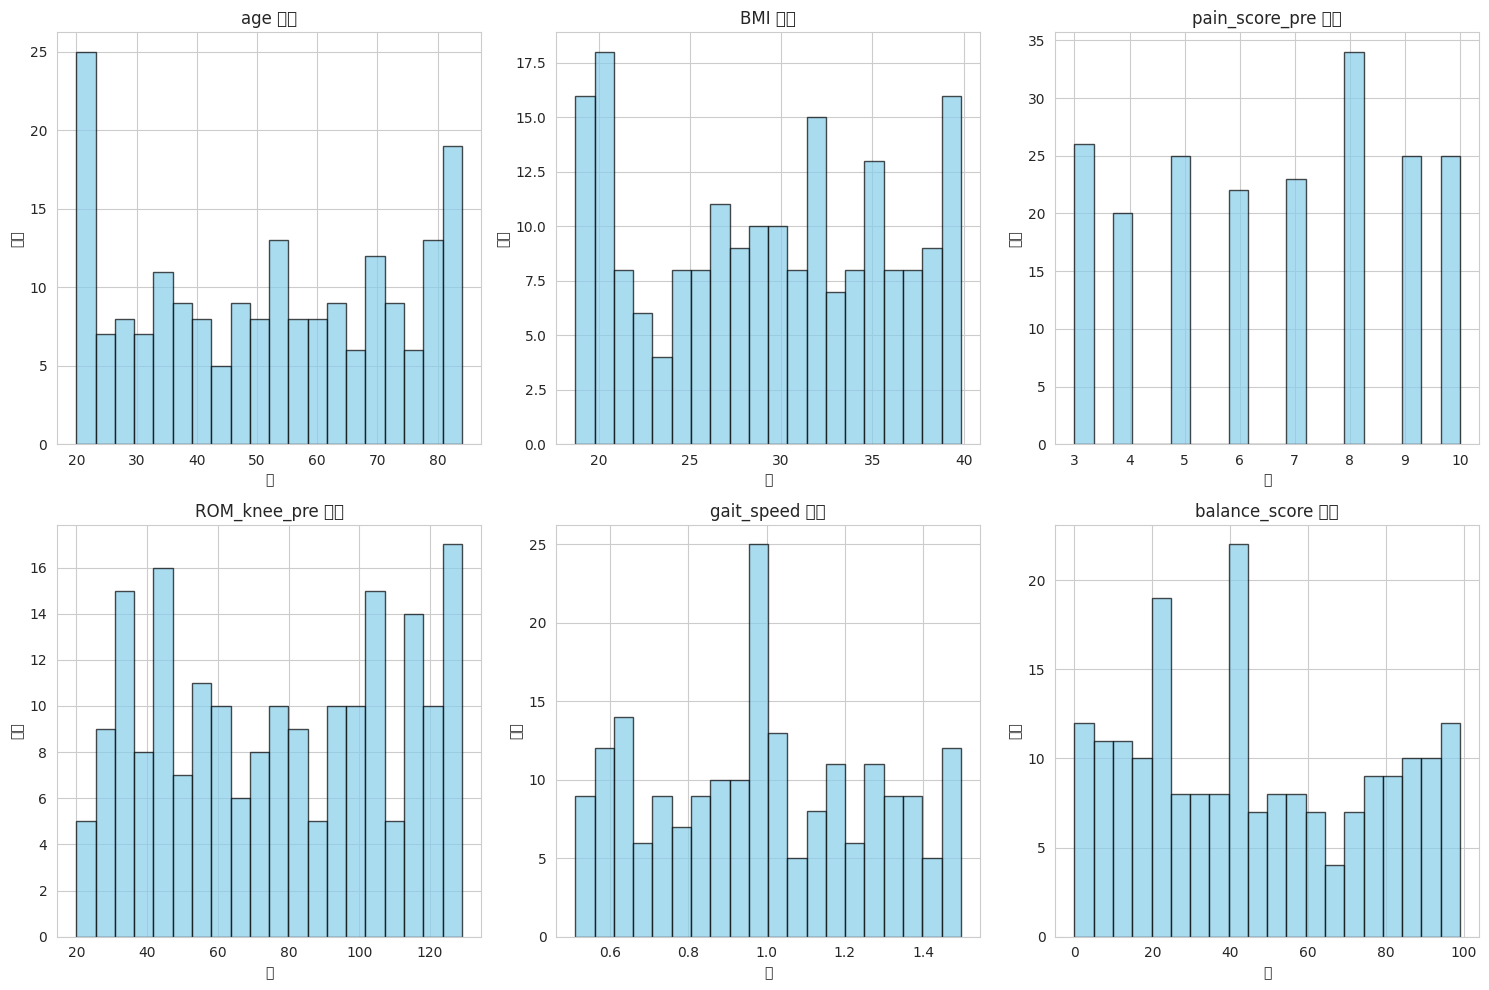

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(['age', 'BMI', 'pain_score_pre', 'ROM_knee_pre', 'gait_speed', 'balance_score']):
    ax = axes[idx]
    ax.hist(df_advanced_clean[col], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(f'{col} 분포')
    ax.set_xlabel('값')
    ax.set_ylabel('빈도')

plt.tight_layout()
plt.savefig(f'{run_output_path}/03_advanced_distributions.png', dpi=300)
plt.show()

In [18]:
from scipy.stats import skew, kurtosis

print('분포 분석')
for col in numeric_cols:
    s = skew(df_advanced_clean[col])
    k = kurtosis(df_advanced_clean[col])
    print(f'{col}: Skewness={s:.3f}, Kurtosis={k:.3f}')

분포 분석
age: Skewness=-0.044, Kurtosis=-1.336
BMI: Skewness=-0.060, Kurtosis=-1.239
pain_score_pre: Skewness=-0.123, Kurtosis=-1.220
ROM_knee_pre: Skewness=-0.001, Kurtosis=-1.339


In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

numeric_cols_all = ['age', 'BMI', 'pain_score_pre', 'ROM_knee_pre', 'grip_strength_pre', 'gait_speed', 'balance_score']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_advanced_clean[numeric_cols_all])

pca = PCA()
pca_result = pca.fit_transform(df_scaled)

cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumsum >= 0.95) + 1

print('PCA 분석')
print(f'95% 분산: {n_components}개 성분')
print('\n각 성분의 분산:')
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f'PC{i+1}: {var*100:.2f}%')

PCA 분석
95% 분산: 7개 성분

각 성분의 분산:
PC1: 18.93%
PC2: 16.38%
PC3: 15.51%
PC4: 13.48%
PC5: 12.65%


/tmp/ipykernel_4384/1004570981.py:18: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/1004570981.py:18: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/1004570981.py:18: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/1004570981.py:18: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/1004570981.py:18: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/1004570981.py:18: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/1004570981.py:18: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tig

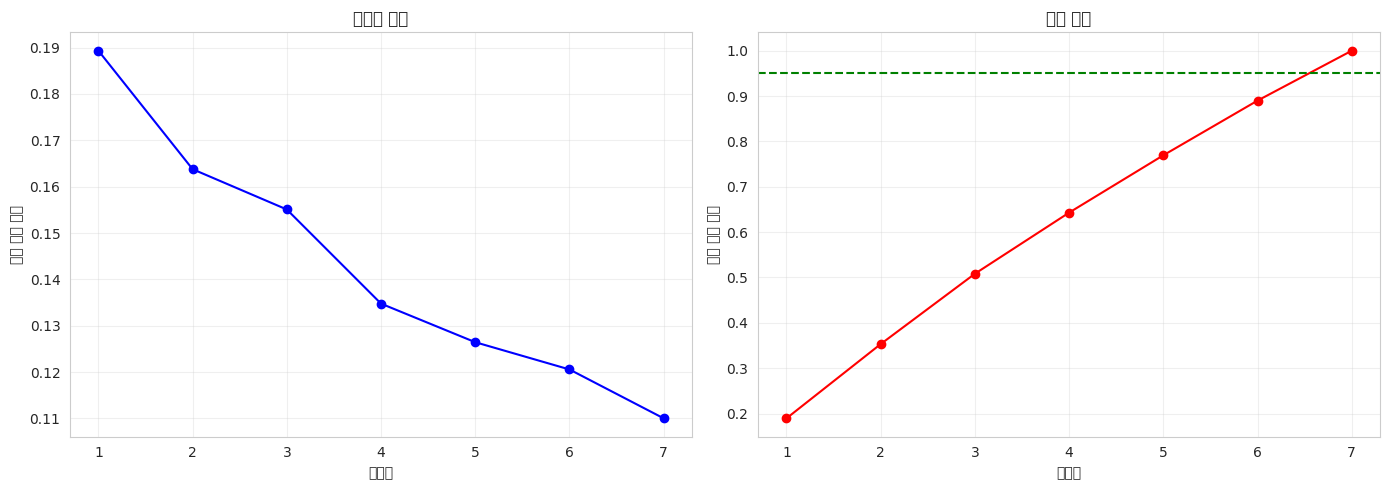

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'bo-')
ax1.set_xlabel('주성분')
ax1.set_ylabel('분산 설명 비율')
ax1.set_title('스크리 플롯')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(range(1, len(cumsum) + 1), cumsum, 'ro-')
ax2.axhline(y=0.95, color='g', linestyle='--')
ax2.set_xlabel('주성분')
ax2.set_ylabel('누적 분산 비율')
ax2.set_title('누적 분산')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{run_output_path}/03_advanced_pca.png', dpi=300)
plt.show()

/tmp/ipykernel_4384/2310204713.py:23: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/2310204713.py:23: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/2310204713.py:23: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/2310204713.py:23: UserWarning: Glyph 47215 (\N{HANGUL SYLLABLE ROS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/2310204713.py:23: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/2310204713.py:23: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/2310204713.py:23: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layo

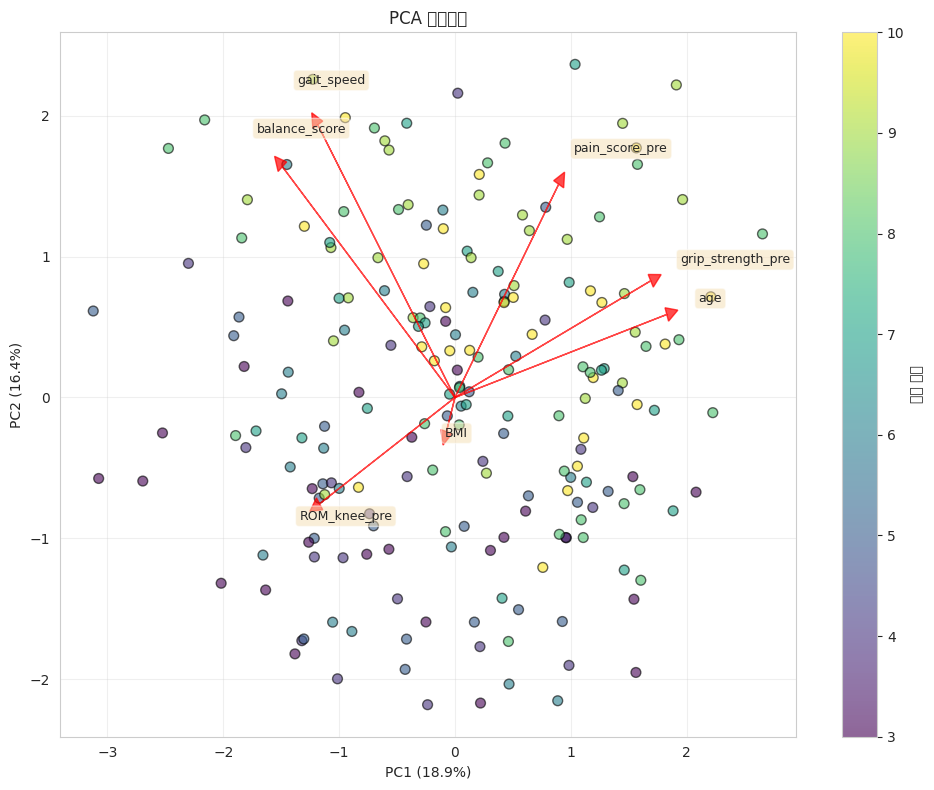

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1],
                     c=df_advanced_clean['pain_score_pre'], cmap='viridis',
                     s=50, alpha=0.6, edgecolors='black')

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
scale = 3
for i, feature in enumerate(numeric_cols_all):
    ax.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
            head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.7)
    ax.text(loadings[i, 0]*scale*1.15, loadings[i, 1]*scale*1.15, feature,
           fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

pc1_var = pca.explained_variance_ratio_[0]*100
pc2_var = pca.explained_variance_ratio_[1]*100
ax.set_xlabel(f'PC1 ({pc1_var:.1f}%)')
ax.set_ylabel(f'PC2 ({pc2_var:.1f}%)')
ax.set_title('PCA 바이플롯')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='초기 통증')

plt.tight_layout()
plt.savefig(f'{run_output_path}/03_advanced_biplot.png', dpi=300)
plt.show()

/tmp/ipykernel_4384/1236407085.py:6: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/1236407085.py:6: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/1236407085.py:6: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/1236407085.py:6: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/1236407085.py:6: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/1236407085.py:6: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4384/1236407085.py:6: UserWarning: Glyph 49437 (\N{HANGUL SYLLABLE SEOG}) missing from font(s) DejaVu Sans.
  plt.tight_la

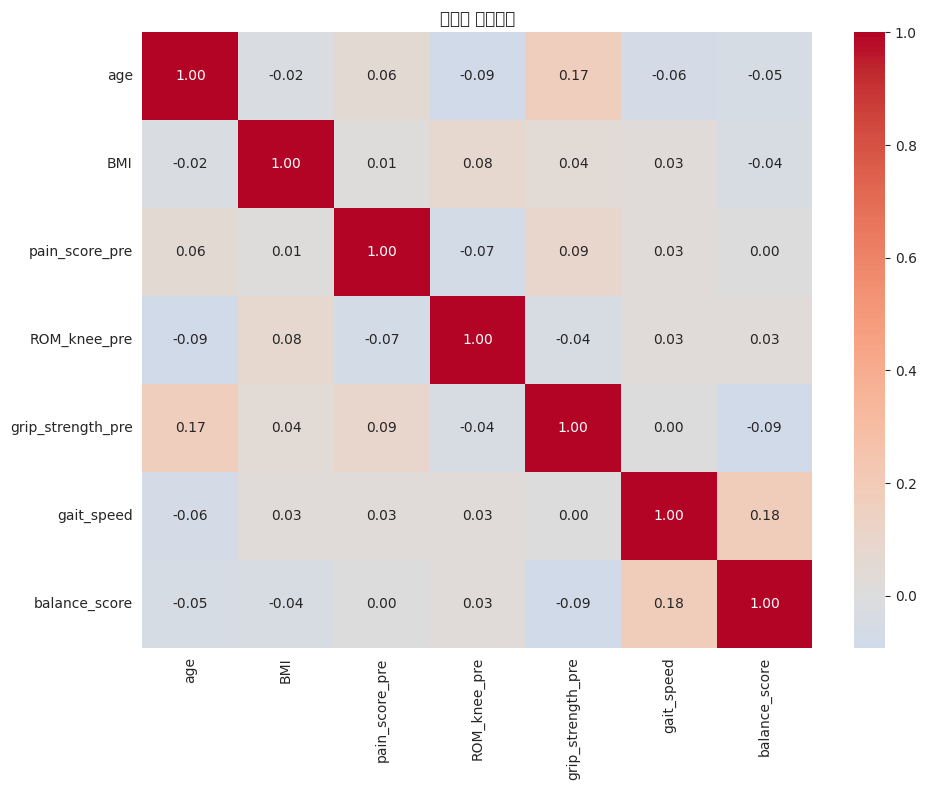

In [22]:
corr_matrix = df_advanced_clean[numeric_cols_all].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('다변량 상관분석')
plt.tight_layout()
plt.savefig(f'{run_output_path}/03_advanced_correlation.png', dpi=300)
plt.show()

In [23]:
report_path = f'{run_output_path}/03_advanced_eda_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('='*70 + '\n')
    f.write('물리치료 데이터 EDA 보고서\n')
    f.write('='*70 + '\n\n')
    f.write(f'생성일: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n')
    f.write(f'[1] 데이터셋\n')
    f.write(f'크기: {df_advanced_clean.shape}\n')
    f.write(f'변수: {len(df_advanced_clean.columns)}\n')
    f.write(f'결측치: 0개\n\n')
    f.write(f'[2] 기술 통계\n')
    f.write(str(df_advanced_clean.describe()))
    f.write(f'\n\n[3] PCA\n')
    f.write(f'95% 분산 성분: {n_components}개\n')
    f.write(f'\n[4] 발견\n')
    f.write(f'평균 나이: {df_advanced_clean["age"].mean():.1f}\n')
    f.write(f'평균 초기 통증: {df_advanced_clean["pain_score_pre"].mean():.1f}\n')

print(f'보고서 저장: {report_path}')

보고서 저장: /content/drive/MyDrive/완석_구글자료/책작업/디지털헬스케어와 물리치료/digitla_pt_code/7week/output/run_20260416_044540/03_advanced_eda_report.txt


In [24]:
df_advanced_clean.to_csv(f'{input_path}/week7_advanced.csv', index=False, encoding='utf-8-sig')

pca_results = pd.DataFrame(pca_result[:, :5], columns=[f'PC{i+1}' for i in range(5)])
pca_results.to_csv(f'{run_output_path}/03_advanced_pca_results.csv', index=False)

print('데이터 저장 완료')
print('\n=== Week 7 분석 완료 ===')
print(f'출력 경로: {run_output_path}')

데이터 저장 완료

=== Week 7 분석 완료 ===
출력 경로: /content/drive/MyDrive/완석_구글자료/책작업/디지털헬스케어와 물리치료/digitla_pt_code/7week/output/run_20260416_044540
